In [1]:
import numpy as np
import matplotlib.pyplot as plt
from turing.kinetics import steady_state
from turing.solver import initial_condition, stable_dt, simulate
from turing.plotting import plot_pattern_2d, plot_profile

In [2]:
""" 
shape : int for 1D array, tuple for 2D array.
"""
a, b, gamma, shape = 0.1, 0.9, 1000, (100, 100)
u0, v0 = initial_condition(shape, a, b)

In [3]:
D, L = 10, 1
dx = L / (shape[0] - 1)
dt = stable_dt(dx, D, u0.ndim)
n_steps, save_every = 1000000, 10000

In [4]:
hist_u, hist_v = simulate(u0, v0, a, b, gamma, D, dx, dt, n_steps, save_every)

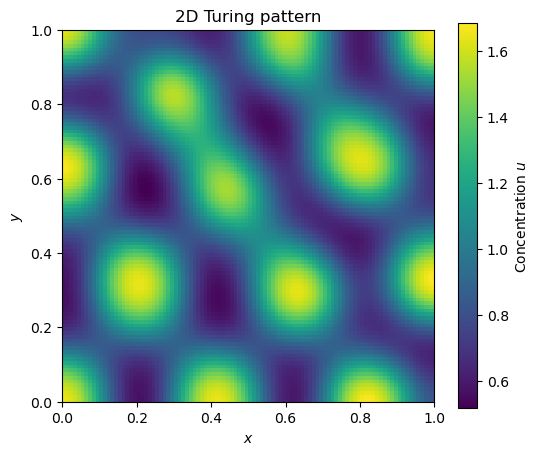

In [5]:
ax = plot_pattern_2d(field=hist_u[-1])

Text(0, 0.5, 'Amplitute')

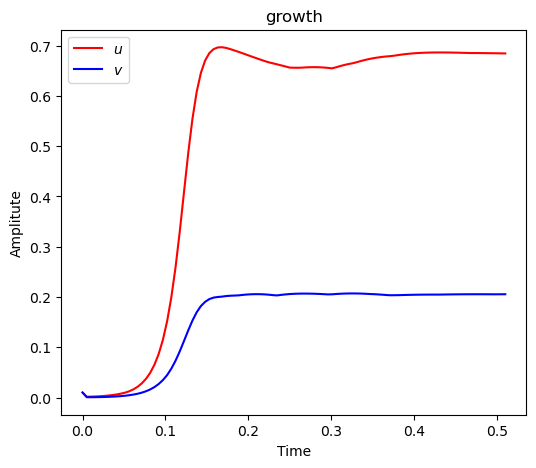

In [ ]:
u_star, v_star = steady_state(a, b)
time = np.arange(len(hist_u)) * (dt * save_every)
amplitude_u = hist_u.max(axis=(1, 2)) - u_star
amplitude_v = hist_v.max(axis=(1, 2)) - v_star

ax2 = plot_profile(u=amplitude_u, v=amplitude_v, x=time)
ax2.set_title('Growth')
ax2.set_xlabel('Time')
ax2.set_ylabel('Amplitute')